# Phase 2 Step 2 — Data Collection (`02_data_collection.ipynb`)

> **목적**: universe 74 unique 종목의 일별 OHLCV + 시장 데이터 + 보조 데이터 수집 → 통합 일별 패널 구축.

## 산출물

| 파일 | 설명 |
|---|---|
| `data/prices_daily/{ticker}.csv` | 74 종목 일별 OHLCV (auto_adjust=True) |
| `data/market_data.csv` | SPY, ^VIX, ^TNX 일별 |
| `data/risk_free.csv` | 무위험 수익률 일별 (^IRX) |
| `data/ff3_monthly.csv` | Fama-French 3팩터 (월별, K-French) |
| **`data/daily_panel.csv`** | ⭐ **통합 일별 패널 (long format)** |

## daily_panel.csv 컬럼

| 컬럼 | 정의 | 출처 |
|---|---|---|
| `date`, `ticker` | (date, ticker) 키 | universe |
| `close` | Adj Close | yfinance |
| `log_ret` | log(close/close.shift(1)) | 계산 |
| `vol_21d` | log_ret.rolling(21).std() | 계산 (Phase 1.5 일관) |
| `vol_60d`, `vol_252d` | 60일, 252일 RV | 계산 |
| `beta_252d` | CAPM β vs SPY | 계산 |
| `mcap_value`, `log_mcap` | close × adjusted_shares | Step 1 캐시 활용 |
| `target_logrv` | log(rolling(21).std()).shift(-21) | ⭐ Phase 1.5 타깃 |
| `gics_sector` | GICS 섹터 | Wikipedia |
| `spy_close`, `spy_log_ret` | SPY 가격·수익률 | 시장 |
| `vix`, `tnx` | 외부지표 | 시장 |
| `rf_daily` | 일별 무위험 수익률 | ^IRX |

## 핵심 — Phase 1.5 와의 정합

```
Phase 1.5 의 입력 채널 (4ch_vix):
  - 채널 1: |log_ret|              ← daily_panel 의 log_ret 활용
  - 채널 2: vol_w (5일 RV)         ← log_ret.rolling(5).std() 자동 계산 가능
  - 채널 3: vol_m (22일 RV)        ← vol_21d 활용
  - 채널 4: VIX z-score            ← daily_panel 의 vix 활용

Phase 1.5 의 타깃: log(rolling(21).std()).shift(-21)
  = daily_panel 의 target_logrv ⭐ (1:1 일치)
```

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 + autoreload |
| §2 | universe ticker list 로드 |
| §3 | OHLCV 다운로드 (74 종목, 캐시) |
| §4 | 시장 데이터 + FF3 + 무위험 수익률 |
| §5 | daily_panel.csv 통합 빌드 |
| §6 | 검증 (결측치, 시점 정렬, 종목별 길이) |
| §7 | 시각화 (시장 데이터 + 종목별 변동성 분포) |


## §1. 환경 부트스트랩

In [1]:
# Jupyter 모듈 자동 리로드
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, BASE_DIR, DATA_DIR, OUTPUTS_DIR
from scripts.data_collection import (
    get_universe_tickers,
    download_universe_ohlcv,
    download_market_data,
    download_risk_free,
    download_fama_french,
    build_daily_panel,
)

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '02_data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nDATA_DIR: {DATA_DIR}')
print(f'OUT_DIR : {OUT_DIR}')

  Phase 2 BL Integration — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility

DATA_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
OUT_DIR : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\outputs\02_data


## §2. Universe Ticker 로드 (Step 1 산출물)

In [2]:
universe_csv = DATA_DIR / 'universe_top50_history.csv'
tickers = get_universe_tickers(universe_csv)
print(f'universe unique 종목 수: {len(tickers)}')
print(f'\n샘플 (앞 20):\n  {tickers[:20]}')

universe unique 종목 수: 74

샘플 (앞 20):
  ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMD', 'AMGN', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BMY', 'BRK-B', 'BX', 'C', 'CAT', 'CHTR', 'CMCSA', 'COP']


## §3. OHLCV 다운로드 (74 종목 일별)

⚠️ **첫 실행**: 약 5~10분 (yfinance 다운로드).
✅ **재실행**: < 5초 (CSV 캐시 활용).

In [3]:
universe_df = pd.read_csv(universe_csv, parse_dates=['cutoff_date'])
earliest_cutoff = universe_df['cutoff_date'].min()
START = earliest_cutoff - pd.DateOffset(years=7)
END = pd.Timestamp(f'{universe_df["oos_year"].max() + 1}-01-01')

print(f'다운로드 기간: {START.date()} ~ {END.date()}')
print(f'예상 영업일: ~{int((END-START).days * 252/365)} 일')

ohlcv_dir = DATA_DIR / 'prices_daily'
ohlcv_map = download_universe_ohlcv(tickers, START, END, ohlcv_dir)

print(f'\n다운로드 완료: {len(ohlcv_map)} 종목')

# 샘플 (AAPL 첫 5 행)
if 'AAPL' in ohlcv_map:
    print(f'\n=== AAPL 샘플 ===')
    print(ohlcv_map['AAPL'].head())

다운로드 기간: 2012-12-31 ~ 2026-01-01
예상 영업일: ~3278 일

다운로드 완료: 74 종목

=== AAPL 샘플 ===
                Open      High       Low     Close     Volume
Date                                                         
2012-12-31 15.432861 16.184660 15.386611 16.087019  659492400
2013-01-02 16.741472 16.777142 16.372980 16.596674  560518000
2013-01-03 16.561912 16.616022 16.353936 16.387188  352965200
2013-01-04 16.232108 16.282289 15.895356 15.930724  594333600
2013-01-07 15.779591 16.000263 15.574033 15.837027  484156400


## §4. 시장 데이터 + Fama-French 3팩터 + 무위험 수익률

In [4]:
# 4-1. 시장 데이터 (SPY, VIX, TNX)
market_path = DATA_DIR / 'market_data.csv'
market = download_market_data(START, END, market_path)
print(f'시장 데이터 shape: {market.shape}')
print(f'컬럼: {list(market.columns)}')
print(f'\n=== 최근 5 행 ===')
print(market.tail())

시장 데이터 shape: (3271, 3)
컬럼: ['SPY', 'TNX', 'VIX']

=== 최근 5 행 ===
                  SPY      TNX       VIX
date                                    
2025-12-24 688.499695 4.136000 13.470000
2025-12-26 688.429871 4.136000 13.600000
2025-12-29 685.976562 4.116000 14.200000
2025-12-30 685.138916 4.130000 14.330000
2025-12-31 680.062744 4.163000 14.950000


In [5]:
# 4-2. Fama-French 3팩터 (월별)
ff3_path = DATA_DIR / 'ff3_monthly.csv'
try:
    ff3 = download_fama_french(ff3_path)
    print(f'\nFF3 shape: {ff3.shape}')
    print(f'컬럼: {list(ff3.columns)}')
    print(f'\n=== 최근 5 행 ===')
    print(ff3.tail())
except Exception as e:
    print(f'FF3 다운로드 실패: {e}')
    print('(FF3 는 옵션 — Pyo & Lee 의 Q 추정에 사용 가능)')


FF3 shape: (1196, 4)
컬럼: ['Mkt-RF', 'SMB', 'HML', 'RF']

=== 최근 5 행 ===
              Mkt-RF       SMB       HML       RF
date                                             
2025-10-31  0.019600 -0.005500 -0.031000 0.003700
2025-11-30 -0.001300  0.003800  0.037600 0.003000
2025-12-31 -0.003600 -0.010600  0.024200 0.003400
2026-01-31  0.010200  0.022000  0.037200 0.003000
2026-02-28 -0.011700  0.001400  0.028300 0.002800


In [6]:
# 4-3. 무위험 수익률 (^IRX 일별)
rf_path = DATA_DIR / 'risk_free.csv'
rf_daily = download_risk_free(START, END, rf_path)
print(f'\nrf_daily shape: {rf_daily.shape}')
print(f'\n=== 최근 5 일 (일별 소수, 연환산 % 환산 시 ×252×100) ===')
recent = rf_daily.tail()
print(recent)
print(f'\n현재 연환산 ≈ {((1 + recent.iloc[-1])**252 - 1)*100:.2f}%')


rf_daily shape: (3270,)

=== 최근 5 일 (일별 소수, 연환산 % 환산 시 ×252×100) ===
date
2025-12-24   0.000139
2025-12-26   0.000138
2025-12-29   0.000138
2025-12-30   0.000138
2025-12-31   0.000138
Name: rf_daily, dtype: float64

현재 연환산 ≈ 3.55%


## §5. 통합 일별 패널 빌드 (`daily_panel.csv`)

각 종목의 lr / vol / beta / mcap / target_logrv 계산 + 시장 데이터 broadcast.

⚠️ **첫 실행**: 1~3분 (74 종목 × 12.7년 피처 계산).
✅ **재실행**: < 5초 (CSV 캐시 활용, `overwrite=True` 시 재계산).

In [7]:
# overwrite=True 로 매 실행마다 강제 재계산 (코드 변경 시 안전)
panel = build_daily_panel(
    universe_csv=universe_csv,
    cache_dir=DATA_DIR,
    overwrite=True,    # ⭐ 항상 최신 코드로 재빌드
)
print(f'\n최종 panel shape: {panel.shape}')
print(f'컬럼: {list(panel.columns)}')

  [data] universe ticker: 74 종목
  [data] 데이터 범위: 2012-12-31 ~ 2026-01-01
  [data] 종목별 피처 계산 중...
    진행: 20/74
    진행: 40/74
    진행: 60/74
  [data] daily_panel 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data\daily_panel.csv
  [data] shape: (241422, 17), 종목 수: 74

최종 panel shape: (241422, 17)
컬럼: ['date', 'close', 'log_ret', 'vol_21d', 'vol_60d', 'vol_252d', 'beta_252d', 'mcap_value', 'log_mcap', 'target_logrv', 'ticker', 'gics_sector', 'spy_close', 'vix', 'tnx', 'spy_log_ret', 'rf_daily']


## §6. 검증

- 종목 수 = 74 (universe 와 일치)
- 결측치 분포
- 종목별 데이터 길이 (≥ 1,732 영업일)
- target_logrv 누수 검증 (Phase 1.5 일관)

In [8]:
# 검증 1: 종목 수
n_tickers = panel['ticker'].nunique()
print(f'종목 수 검증: {n_tickers} (예상 74) {"✅" if n_tickers == 74 else "⚠️"}')

# 검증 2: 종목별 길이
counts = panel.groupby('ticker').size().sort_values()
print(f'\n종목별 행 수 통계:')
print(f'  최소: {counts.min()}, 최대: {counts.max()}, 평균: {counts.mean():.0f}, 중앙값: {counts.median():.0f}')
print(f'  1,732 미만 종목: {(counts < 1732).sum()} (예상 0)')

# 검증 3: 결측치
print(f'\n주요 컬럼 결측치 비율:')
key_cols = ['close', 'log_ret', 'vol_21d', 'beta_252d', 'mcap_value', 'target_logrv']
for col in key_cols:
    if col in panel.columns:
        nan_pct = panel[col].isna().mean() * 100
        print(f'  {col:15s}: {nan_pct:5.1f}%')

종목 수 검증: 74 (예상 74) ✅

종목별 행 수 통계:
  최소: 2640, 최대: 3271, 평균: 3262, 중앙값: 3271
  1,732 미만 종목: 0 (예상 0)

주요 컬럼 결측치 비율:
  close          :   0.0%
  log_ret        :   0.0%
  vol_21d        :   0.6%
  beta_252d      :   7.7%
  mcap_value     :  22.8%
  target_logrv   :   0.6%


In [9]:
# 검증 4: target_logrv 누수 검증
# Phase 1.5 와 동일: target[t] = log( log_ret[t+1:t+22].std() )
# → 첫 21행 + 마지막 21행 NaN 이어야 함

sample_ticker = 'AAPL' if 'AAPL' in panel['ticker'].values else panel['ticker'].iloc[0]
df_aapl = panel[panel['ticker'] == sample_ticker].sort_values('date').reset_index(drop=True)
print(f'=== {sample_ticker} target_logrv 누수 검증 ===\n')

# 임의 시점 t 검증
test_idx = 100
d = df_aapl.loc[test_idx, 'date']
target_at_t = df_aapl.loc[test_idx, 'target_logrv']
# 수동 계산: t+1 ~ t+21 일별 log_ret 의 std → log
future_lr = df_aapl.loc[test_idx+1:test_idx+21, 'log_ret']
manual = np.log(future_lr.std())
print(f'시점 t={test_idx} ({d.date()}):')
print(f'  panel target_logrv: {target_at_t:.6f}')
print(f'  수동 계산:          {manual:.6f}')
diff = abs(target_at_t - manual)
print(f'  차이: {diff:.2e} {"✅" if diff < 1e-6 else "⚠️"}')


=== AAPL target_logrv 누수 검증 ===

시점 t=100 (2013-05-24):
  panel target_logrv: -4.560160
  수동 계산:          -4.560160
  차이: 1.78e-15 ✅


## §7. 시각화

- 시장 데이터 (SPY, VIX, TNX) 시계열
- 종목별 변동성 분포 (vol_252d)
- target_logrv 분포

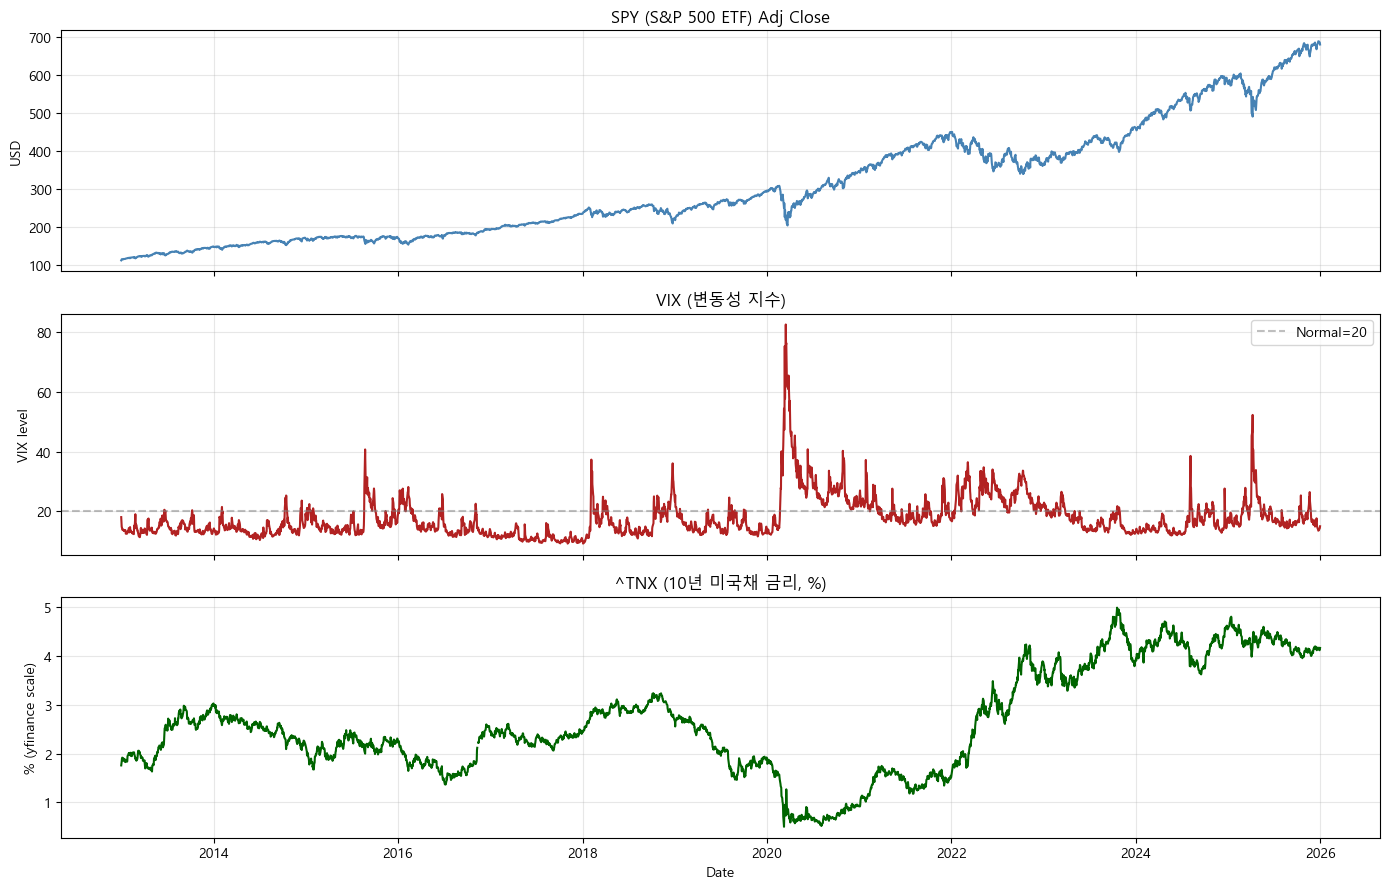

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 7-1. SPY
axes[0].plot(market.index, market['SPY'], color='steelblue')
axes[0].set_title('SPY (S&P 500 ETF) Adj Close')
axes[0].set_ylabel('USD')
axes[0].grid(alpha=0.3)

# 7-2. VIX
axes[1].plot(market.index, market['VIX'], color='firebrick')
axes[1].set_title('VIX (변동성 지수)')
axes[1].set_ylabel('VIX level')
axes[1].axhline(20, color='gray', ls='--', alpha=0.5, label='Normal=20')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 7-3. ^TNX (10년 국채 금리)
axes[2].plot(market.index, market['TNX'], color='darkgreen')
axes[2].set_title('^TNX (10년 미국채 금리, %)')
axes[2].set_ylabel('% (yfinance scale)')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'market_data.png', dpi=120, bbox_inches='tight')
plt.show()

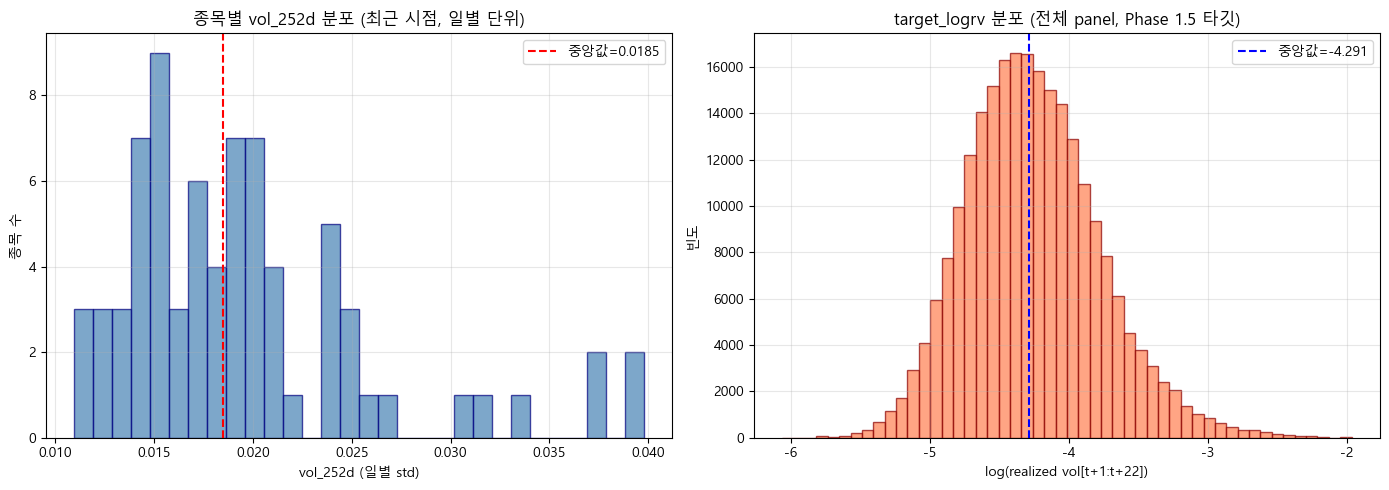

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7-4. 종목별 vol_252d 분포 (가장 최근 시점)
latest = panel.dropna(subset=['vol_252d']).groupby('ticker').last()
axes[0].hist(latest['vol_252d'].dropna(), bins=30, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].axvline(latest['vol_252d'].median(), color='red', ls='--',
                label=f'중앙값={latest["vol_252d"].median():.4f}')
axes[0].set_title('종목별 vol_252d 분포 (최근 시점, 일별 단위)')
axes[0].set_xlabel('vol_252d (일별 std)')
axes[0].set_ylabel('종목 수')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 7-5. target_logrv 분포 (전체 panel)
axes[1].hist(panel['target_logrv'].dropna(), bins=50, color='coral', edgecolor='darkred', alpha=0.7)
axes[1].axvline(panel['target_logrv'].median(), color='blue', ls='--',
                label=f'중앙값={panel["target_logrv"].median():.3f}')
axes[1].set_title('target_logrv 분포 (전체 panel, Phase 1.5 타깃)')
axes[1].set_xlabel('log(realized vol[t+1:t+22])')
axes[1].set_ylabel('빈도')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 다음 단계

→ **Step 3**: `03_phase15_ensemble_top50.ipynb` — Phase 1.5 v8 ensemble 을 74 종목으로 확장 학습.

`daily_panel.csv` 의 `log_ret`, `vol_21d` 등이 ensemble 입력으로, `target_logrv` 가 평가 타깃으로 사용됨.